In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
    hamming_loss,
    label_ranking_loss,
    coverage_error,
    matthews_corrcoef
)
from sklearn.calibration import calibration_curve

In [ ]:
# ------------------ CONFIG ------------------

ROOT = Path.cwd().resolve()
while not (ROOT / "results").exists():
    ROOT = ROOT.parent

FILES = {
    "Classical Mamba": ROOT / "results/classical-mamba/ClassicalMamba_Wafer_Results.json",
    "Hybrid Mamba": ROOT / "results/hybrid-mamba/HybridMamba_Wafer_Results.json",
    "ResNet": ROOT / "results/resnet/Resnet_Wafer_Results.json",
    "Vision Transformer": ROOT / "results/vit/VisionTransformer_Wafer_Results.json",
}


CLASSES = [
    "Center",
    "Donut",
    "Edge_Loc",
    "Edge_Ring",
    "Loc",
    "Near_Full",
    "Scratch",
    "Random",
]

THRESHOLD = 0.5
RARE_CLASS = "Near_Full"


In [22]:
# ------------------ LOAD ------------------

def load(path):
    with open(path) as f:
        d = json.load(f)
    logits = np.array(d["test_data"]["logits"])
    y_true = np.array(d["test_data"]["labels"])
    y_prob = 1 / (1 + np.exp(-logits))
    y_pred = (y_prob >= THRESHOLD).astype(int)
    return y_true, y_prob, y_pred

models = {k: load(v) for k, v in FILES.items()}

In [23]:
# ------------------ 1. CLASSIFICATION REPORTS ------------------

for name, (y_true, _, y_pred) in models.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print(classification_report(
        y_true, y_pred, target_names=CLASSES, digits=6, zero_division=0
    ))


Classical Mamba
              precision    recall  f1-score   support

      Center   0.999227  0.998069  0.998648      2590
       Donut   1.000000  1.000000  1.000000      2400
    Edge_Loc   0.994949  0.983865  0.989376      2603
   Edge_Ring   0.988632  0.997451  0.993022      2354
         Loc   0.998303  0.986309  0.992270      3579
   Near_Full   0.805556  0.966667  0.878788        30
     Scratch   0.995395  0.978174  0.986710      3757
      Random   1.000000  0.948276  0.973451       174

   micro avg   0.995854  0.988906  0.992368     17487
   macro avg   0.972758  0.982351  0.976533     17487
weighted avg   0.995933  0.988906  0.992369     17487
 samples avg   0.967938  0.962706  0.964421     17487


Hybrid Mamba
              precision    recall  f1-score   support

      Center   1.000000  0.998842  0.999421      2590
       Donut   1.000000  1.000000  1.000000      2400
    Edge_Loc   0.993791  0.983865  0.988803      2603
   Edge_Ring   0.990717  0.997451  0.994073    

In [24]:
# ------------------ 2. GLOBAL METRICS TABLE ------------------

rows = []
for name, (y_true, _, y_pred) in models.items():
    rows.append({
        "Model": name,
        "Micro-F1": f1_score(y_true, y_pred, average="micro"),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
        "Samples-F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
    })

df_metrics = pd.DataFrame(rows)
print("\nFINAL METRICS TABLE\n")
print(df_metrics)


FINAL METRICS TABLE

                Model  Micro-F1  Macro-F1  Weighted-F1  Samples-F1
0     Classical Mamba  0.992368  0.976533     0.992369    0.964421
1        Hybrid Mamba  0.993230  0.979771     0.993222    0.964727
2              ResNet  0.987349  0.969194     0.987301    0.959448
3  Vision Transformer  0.992948  0.979341     0.992948    0.965044


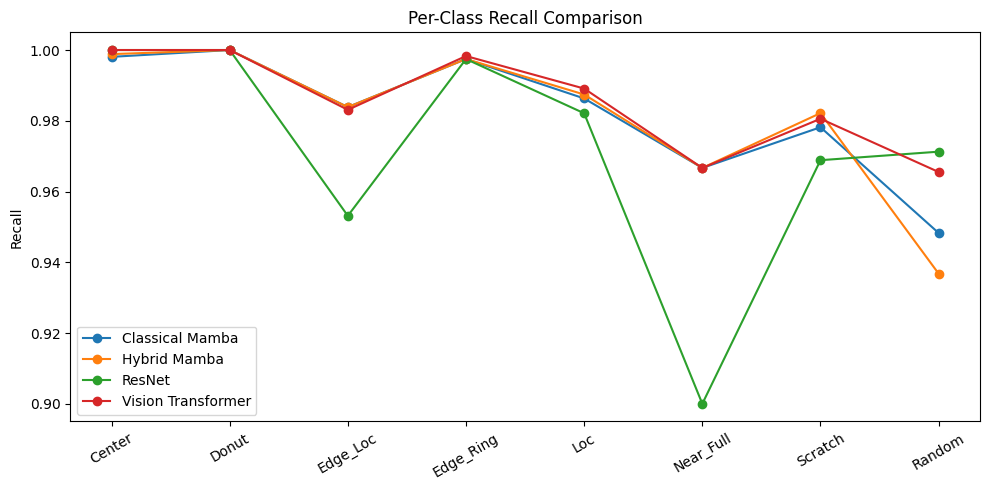

In [25]:
# ------------------ 3. PER-CLASS RECALL BAR PLOT ------------------

plt.figure(figsize=(10,5))
for name, (y_true, _, y_pred) in models.items():
    recall = [
        np.logical_and(y_pred[:, i], y_true[:, i]).sum() / y_true[:, i].sum()
        for i in range(len(CLASSES))
    ]
    plt.plot(CLASSES, recall, marker="o", label=name)

plt.ylabel("Recall")
plt.xticks(rotation=30)
plt.legend()
plt.title("Per-Class Recall Comparison")
plt.tight_layout()
plt.show()

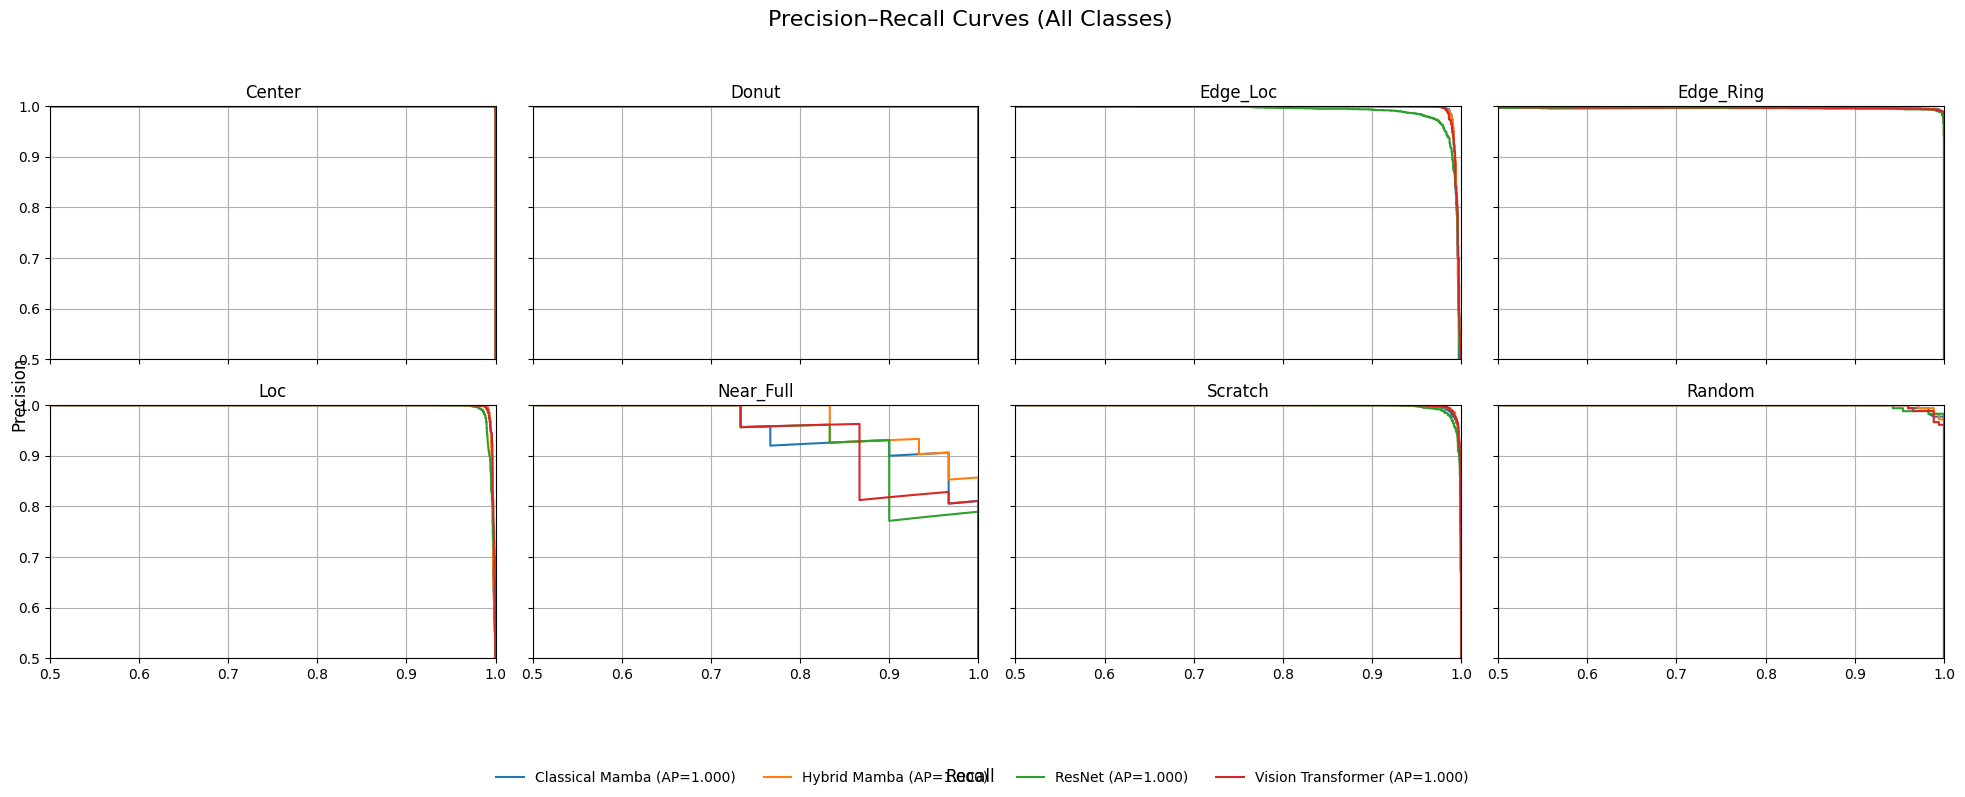

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for c, cls in enumerate(CLASSES):
    ax = axes[c]
    for name, (y_true, y_prob, _) in models.items():
        p, r, _ = precision_recall_curve(y_true[:, c], y_prob[:, c])
        ap = average_precision_score(y_true[:, c], y_prob[:, c])
        ax.plot(r, p, label=f"{name} (AP={ap:.3f})")

    ax.set_title(cls)
    ax.set_xlim(0.5, 1)
    ax.set_ylim(0.5, 1)
    ax.grid(True)

fig.supxlabel("Recall")
fig.supylabel("Precision")
fig.suptitle("Precision–Recall Curves (All Classes)", fontsize=16)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()


In [27]:
# ------------------ 6. mAP TABLE ------------------

map_rows = []
for name, (y_true, y_prob, _) in models.items():
    aps = [
        average_precision_score(y_true[:,i], y_prob[:,i])
        for i in range(len(CLASSES))
    ]
    map_rows.append({"Model": name, "mAP": np.mean(aps)})

print("\nmAP COMPARISON\n")
print(pd.DataFrame(map_rows))


mAP COMPARISON

                Model       mAP
0     Classical Mamba  0.995947
1        Hybrid Mamba  0.997274
2              ResNet  0.994504
3  Vision Transformer  0.995488


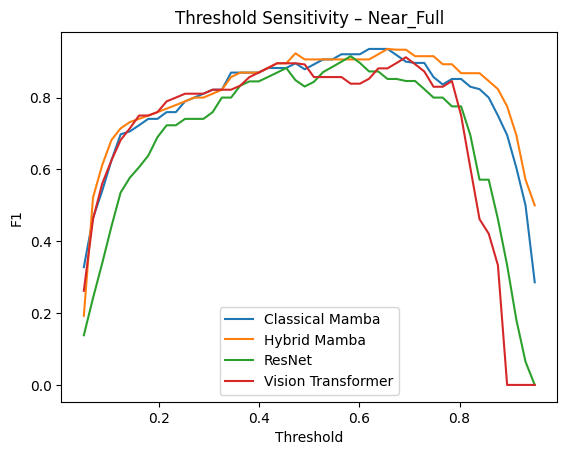

In [28]:
# ------------------ 7. THRESHOLD SENSITIVITY (RARE CLASS) ------------------

idx = CLASSES.index(RARE_CLASS)
ts = np.linspace(0.05, 0.95, 50)

plt.figure()
for name, (y_true, y_prob, _) in models.items():
    f1s = [
        f1_score(y_true[:,idx], (y_prob[:,idx]>=t).astype(int), zero_division=0)
        for t in ts
    ]
    plt.plot(ts, f1s, label=name)

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title(f"Threshold Sensitivity – {RARE_CLASS}")
plt.legend()
plt.show()

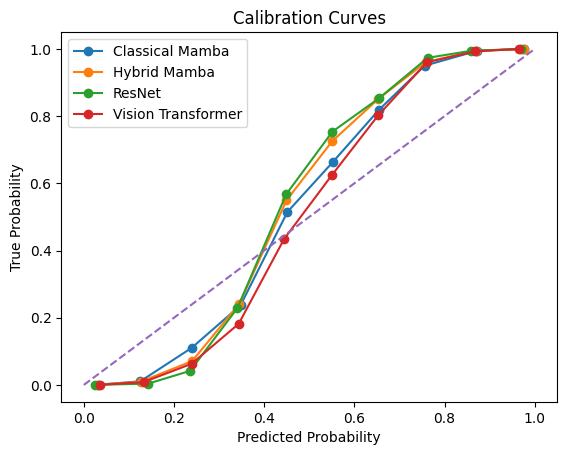

In [29]:
# ------------------ 8–9. CALIBRATION CURVES ------------------

plt.figure()
for name, (y_true, y_prob, _) in models.items():
    prob_true, prob_pred = calibration_curve(
        y_true.ravel(), y_prob.ravel(), n_bins=10
    )
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curves")
plt.legend()
plt.show()

In [30]:
# ------------------ 10–11. ECE + BRIER ------------------

def ece(y_true, y_prob, bins=10):
    binids = np.digitize(y_prob, np.linspace(0,1,bins+1)) - 1
    ece = 0
    for b in range(bins):
        m = binids == b
        if m.any():
            ece += abs(y_true[m].mean() - y_prob[m].mean()) * m.mean()
    return ece

print("\nCALIBRATION METRICS\n")
for name, (y_true, y_prob, _) in models.items():
    print(
        name,
        "ECE:", round(ece(y_true.ravel(), y_prob.ravel()),4),
        "Brier:", round(brier_score_loss(y_true.ravel(), y_prob.ravel()),4)
    )


CALIBRATION METRICS

Classical Mamba ECE: 0.039 Brier: 0.0064
Hybrid Mamba ECE: 0.0403 Brier: 0.0063
ResNet ECE: 0.055 Brier: 0.0118
Vision Transformer ECE: 0.0469 Brier: 0.007


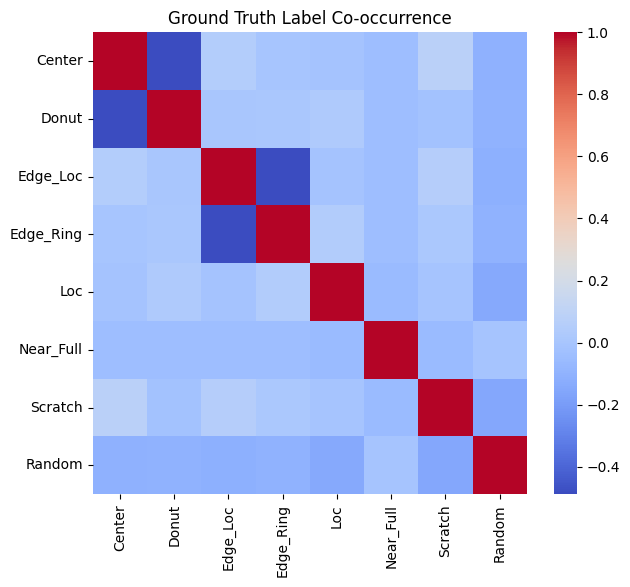

In [31]:
# ------------------ 12. CO-OCCURRENCE HEATMAP ------------------

y_true_all = list(models.values())[0][0]
co = np.corrcoef(y_true_all.T)

plt.figure(figsize=(7,6))
sns.heatmap(co, xticklabels=CLASSES, yticklabels=CLASSES, cmap="coolwarm")
plt.title("Ground Truth Label Co-occurrence")
plt.show()

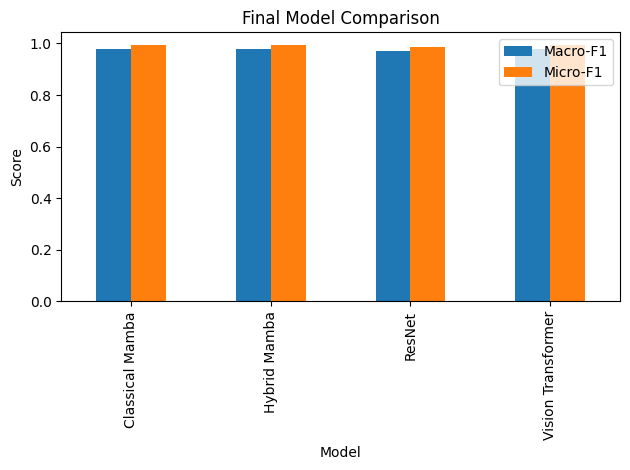

In [32]:
# ------------------ 13. FINAL BAR SUMMARY ------------------

df_metrics.set_index("Model")[["Macro-F1","Micro-F1"]].plot(kind="bar")
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [33]:
# ------------------ LABEL RANKING METRICS ------------------

print("\nLABEL RANKING METRICS\n")

for name, (y_true, y_prob, _) in models.items():
    print(
        f"{name:20s}",
        "Ranking Loss:", round(label_ranking_loss(y_true, y_prob), 5),
        "Coverage Error:", round(coverage_error(y_true, y_prob), 3)
    )


LABEL RANKING METRICS

Classical Mamba      Ranking Loss: 0.00069 Coverage Error: 2.308
Hybrid Mamba         Ranking Loss: 0.00056 Coverage Error: 2.306
ResNet               Ranking Loss: 0.00097 Coverage Error: 2.311
Vision Transformer   Ranking Loss: 0.00056 Coverage Error: 2.306


In [34]:
# ------------------ HAMMING LOSS ------------------

print("\nHAMMING LOSS\n")

for name, (y_true, _, y_pred) in models.items():
    print(
        f"{name:20s}",
        round(hamming_loss(y_true, y_pred), 5)
    )



HAMMING LOSS

Classical Mamba      0.00437
Hybrid Mamba         0.00388
ResNet               0.00723
Vision Transformer   0.00404


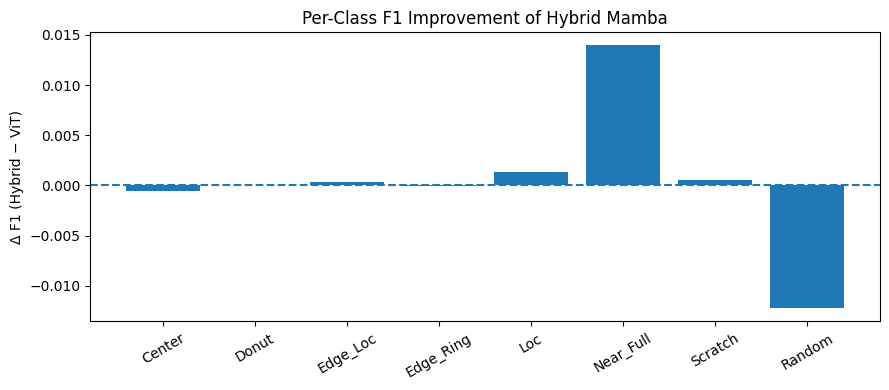

In [35]:
# ------------------ PER-CLASS F1 DIFFERENCE BAR PLOT ------------------

hy_true, _, hy_pred = models["Hybrid Mamba"]
vt_true, _, vt_pred = models["Vision Transformer"]

f1_hybrid = [
    f1_score(hy_true[:, i], hy_pred[:, i], zero_division=0)
    for i in range(len(CLASSES))
]

f1_vit = [
    f1_score(vt_true[:, i], vt_pred[:, i], zero_division=0)
    for i in range(len(CLASSES))
]

delta = np.array(f1_hybrid) - np.array(f1_vit)

plt.figure(figsize=(9, 4))
plt.bar(CLASSES, delta)
plt.axhline(0, linestyle="--")
plt.ylabel("Δ F1 (Hybrid − ViT)")
plt.title("Per-Class F1 Improvement of Hybrid Mamba")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


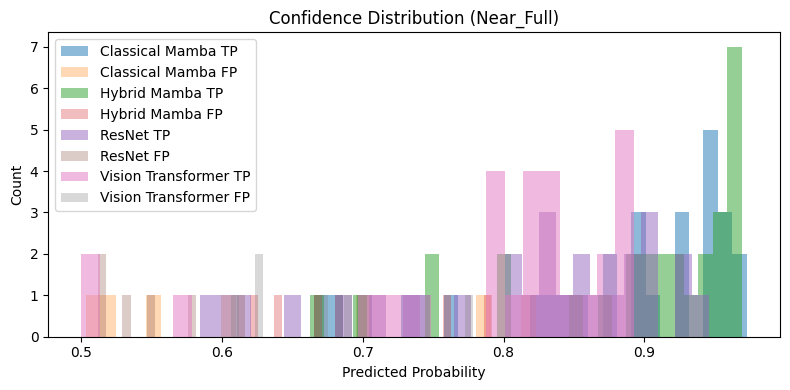

In [36]:
# ------------------ CONFIDENCE DISTRIBUTION (RARE CLASS) ------------------

cls_idx = CLASSES.index("Near_Full")

plt.figure(figsize=(8,4))

for name, (y_true, y_prob, y_pred) in models.items():
    tp = y_prob[:, cls_idx][(y_true[:, cls_idx] == 1) & (y_pred[:, cls_idx] == 1)]
    fp = y_prob[:, cls_idx][(y_true[:, cls_idx] == 0) & (y_pred[:, cls_idx] == 1)]

    plt.hist(tp, bins=30, alpha=0.5, label=f"{name} TP")
    plt.hist(fp, bins=30, alpha=0.3, label=f"{name} FP")

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Confidence Distribution (Near_Full)")
plt.legend()
plt.tight_layout()
plt.show()

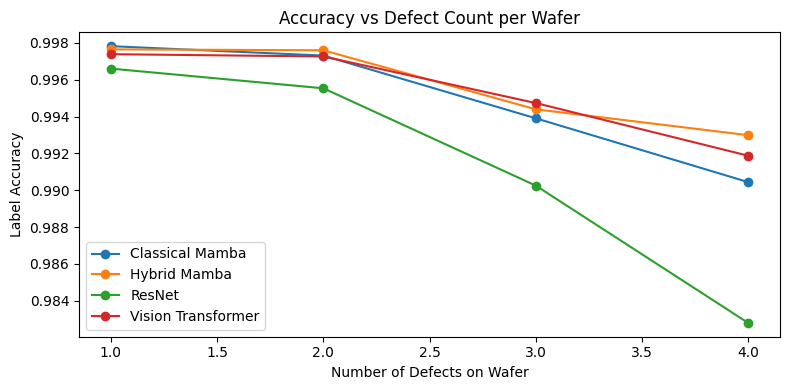

In [37]:
# ------------------ ACCURACY VS DEFECT COUNT PER WAFER ------------------

plt.figure(figsize=(8,4))

for name, (y_true, _, y_pred) in models.items():
    counts = y_true.sum(axis=1)
    acc = []

    for k in range(1, 5):
        mask = counts == k
        if mask.any():
            acc.append((y_pred[mask] == y_true[mask]).mean())
        else:
            acc.append(np.nan)

    plt.plot(range(1,5), acc, marker="o", label=name)

plt.xlabel("Number of Defects on Wafer")
plt.ylabel("Label Accuracy")
plt.title("Accuracy vs Defect Count per Wafer")
plt.legend()
plt.tight_layout()
plt.show()

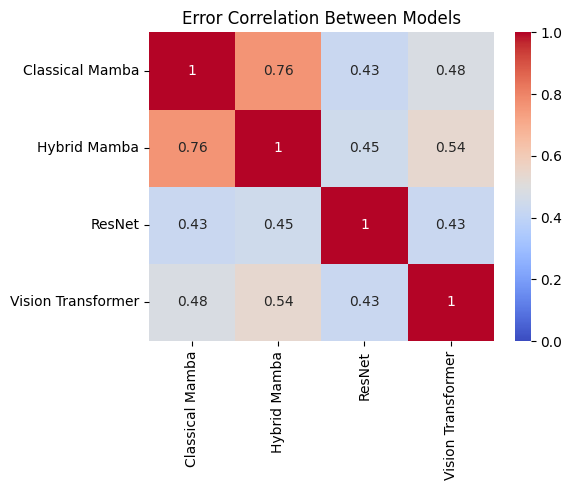

In [38]:
# ------------------ ERROR CORRELATION HEATMAP ------------------

errors = {}

for name, (y_true, _, y_pred) in models.items():
    errors[name] = ((y_true != y_pred).sum(axis=1) > 0).astype(int)

err_mat = pd.DataFrame(errors).corr()

plt.figure(figsize=(6,5))
sns.heatmap(err_mat, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Error Correlation Between Models")
plt.tight_layout()
plt.show()

In [39]:
# ------------------ ERROR SUMMARY (PER-CLASS FN / FP) ------------------

print("\nERROR SUMMARY (Per-Class FN / FP)\n")

for name, (y_true, _, y_pred) in models.items():
    print(name)
    for i, cls in enumerate(CLASSES):
        fn = ((y_true[:, i] == 1) & (y_pred[:, i] == 0)).sum()
        fp = ((y_true[:, i] == 0) & (y_pred[:, i] == 1)).sum()
        print(f"  {cls:12s} FN={fn:5d} FP={fp:5d}")
    print()


ERROR SUMMARY (Per-Class FN / FP)

Classical Mamba
  Center       FN=    5 FP=    2
  Donut        FN=    0 FP=    0
  Edge_Loc     FN=   42 FP=   13
  Edge_Ring    FN=    6 FP=   27
  Loc          FN=   49 FP=    6
  Near_Full    FN=    1 FP=    7
  Scratch      FN=   82 FP=   17
  Random       FN=    9 FP=    0

Hybrid Mamba
  Center       FN=    3 FP=    0
  Donut        FN=    0 FP=    0
  Edge_Loc     FN=   42 FP=   16
  Edge_Ring    FN=    6 FP=   22
  Loc          FN=   45 FP=    3
  Near_Full    FN=    1 FP=    5
  Scratch      FN=   67 FP=   15
  Random       FN=   11 FP=    0

ResNet
  Center       FN=    0 FP=    0
  Donut        FN=    0 FP=    0
  Edge_Loc     FN=  122 FP=   39
  Edge_Ring    FN=    6 FP=   29
  Loc          FN=   64 FP=   22
  Near_Full    FN=    3 FP=    7
  Scratch      FN=  117 FP=   24
  Random       FN=    5 FP=    2

Vision Transformer
  Center       FN=    0 FP=    0
  Donut        FN=    0 FP=    0
  Edge_Loc     FN=   44 FP=   16
  Edge_Ring    

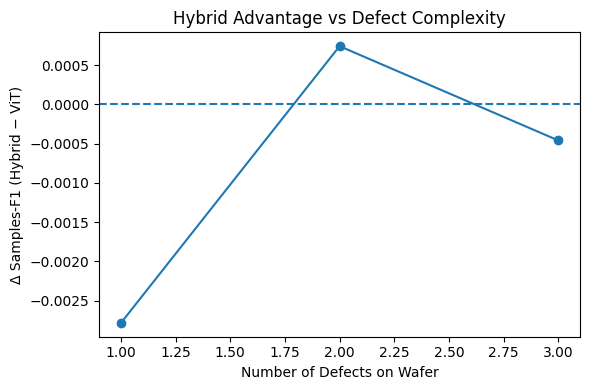

In [40]:
# ---------------- ΔF1 vs Defect Complexity (Hybrid − ViT) ------------------
hy_true, _, hy_pred = models["Hybrid Mamba"]
vt_true, _, vt_pred = models["Vision Transformer"]

counts = hy_true.sum(axis=1)
levels = [1, 2, 3]

delta_f1 = []
for k in levels:
    mask = counts == k
    if mask.any():
        f1_h = f1_score(hy_true[mask], hy_pred[mask], average="samples", zero_division=0)
        f1_v = f1_score(vt_true[mask], vt_pred[mask], average="samples", zero_division=0)
        delta_f1.append(f1_h - f1_v)
    else:
        delta_f1.append(np.nan)

plt.figure(figsize=(6,4))
plt.plot(levels, delta_f1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Number of Defects on Wafer")
plt.ylabel("Δ Samples-F1 (Hybrid − ViT)")
plt.title("Hybrid Advantage vs Defect Complexity")
plt.tight_layout()
plt.show()

In [41]:
# ------------------ CONDITIONAL CO-OCCURRENCE F1 ------------------

pairs = [
    ("Edge_Loc", "Scratch"),
    ("Edge_Ring", "Loc"),
]

print("\nCONDITIONAL CO-OCCURRENCE F1\n")

for a, b in pairs:
    i, j = CLASSES.index(a), CLASSES.index(b)
    mask = (hy_true[:, i] == 1) & (hy_true[:, j] == 1)

    if mask.any():
        f1_h = f1_score(hy_true[mask], hy_pred[mask], average="samples", zero_division=0)
        f1_v = f1_score(vt_true[mask], vt_pred[mask], average="samples", zero_division=0)
        print(f"{a}+{b:12s} Hybrid={f1_h:.4f}  ViT={f1_v:.4f}")


CONDITIONAL CO-OCCURRENCE F1

Edge_Loc+Scratch      Hybrid=0.9896  ViT=0.9898
Edge_Ring+Loc          Hybrid=0.9940  ViT=0.9943


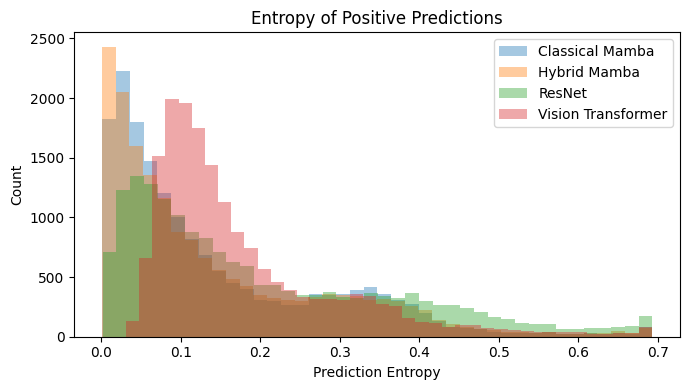

In [42]:
# ------------------ ENTROPY OF POSITIVE PREDICTIONS ------------------

def entropy(p):
    eps = 1e-9
    return -(p*np.log(p+eps) + (1-p)*np.log(1-p+eps))

plt.figure(figsize=(7,4))

for name, (_, y_prob, y_pred) in models.items():
    ent = entropy(y_prob)
    plt.hist(ent[y_pred == 1], bins=40, alpha=0.4, label=name)

plt.xlabel("Prediction Entropy")
plt.ylabel("Count")
plt.title("Entropy of Positive Predictions")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# ------------------ LABEL RANKING STABILITY (Kendall τ) ------------------

from scipy.stats import kendalltau

noise = 0.01
print("\nLABEL RANKING STABILITY (Kendall τ)\n")

for name, (_, y_prob, _) in models.items():
    noisy = y_prob + noise * np.random.randn(*y_prob.shape)
    taus = []
    for i in range(len(y_prob)):
        tau, _ = kendalltau(y_prob[i], noisy[i])
        if not np.isnan(tau):
            taus.append(tau)
    print(f"{name:20s} τ={np.mean(taus):.4f}")


LABEL RANKING STABILITY (Kendall τ)

Classical Mamba      τ=0.8647
Hybrid Mamba         τ=0.8729
ResNet               τ=0.9038
Vision Transformer   τ=0.8629


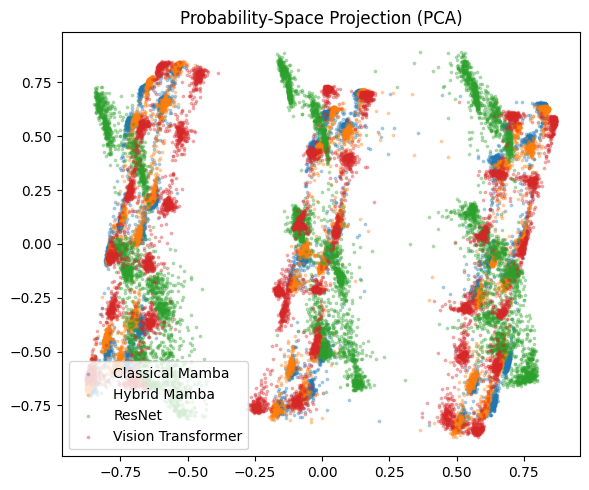

In [44]:
# ------------------ PROBABILITY-SPACE PROJECTION (PCA) ------------------

from sklearn.decomposition import PCA

plt.figure(figsize=(6,5))
for name, (_, y_prob, _) in models.items():
    emb = PCA(n_components=2).fit_transform(y_prob)
    plt.scatter(emb[:,0], emb[:,1], s=3, alpha=0.3, label=name)

plt.title("Probability-Space Projection (PCA)")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# ------------------ MATTHEWS CORRELATION COEFFICIENT (PER CLASS) ------------------

print("\nMATTHEWS CORRELATION COEFFICIENT (PER CLASS)\n")

for name, (y_true, _, y_pred) in models.items():
    print(name)
    for i, cls in enumerate(CLASSES):
        mcc = matthews_corrcoef(y_true[:, i], y_pred[:, i])
        print(f"  {cls:12s} MCC={mcc:.4f}")


MATTHEWS CORRELATION COEFFICIENT (PER CLASS)

Classical Mamba
  Center       MCC=0.9980
  Donut        MCC=1.0000
  Edge_Loc     MCC=0.9839
  Edge_Ring    MCC=0.9899
  Loc          MCC=0.9855
  Near_Full    MCC=0.8819
  Scratch      MCC=0.9741
  Random       MCC=0.9732
Hybrid Mamba
  Center       MCC=0.9991
  Donut        MCC=1.0000
  Edge_Loc     MCC=0.9830
  Edge_Ring    MCC=0.9914
  Loc          MCC=0.9874
  Near_Full    MCC=0.9076
  Scratch      MCC=0.9785
  Random       MCC=0.9672
ResNet
  Center       MCC=1.0000
  Donut        MCC=1.0000
  Edge_Loc     MCC=0.9529
  Edge_Ring    MCC=0.9893
  Loc          MCC=0.9773
  Near_Full    MCC=0.8448
  Scratch      MCC=0.9632
  Random       MCC=0.9793
Vision Transformer
  Center       MCC=1.0000
  Donut        MCC=1.0000
  Edge_Loc     MCC=0.9825
  Edge_Ring    MCC=0.9914
  Loc          MCC=0.9847
  Near_Full    MCC=0.8945
  Scratch      MCC=0.9775
  Random       MCC=0.9792


In [46]:
# ------------------ SUBSET ACCURACY (Exact Match) ------------------

print("\nSUBSET ACCURACY (Exact Match)\n")

for name, (y_true, _, y_pred) in models.items():
    exact = (y_true == y_pred).all(axis=1).mean()
    print(f"{name:20s} {exact:.4f}")


SUBSET ACCURACY (Exact Match)

Classical Mamba      0.9703
Hybrid Mamba         0.9737
ResNet               0.9474
Vision Transformer   0.9726


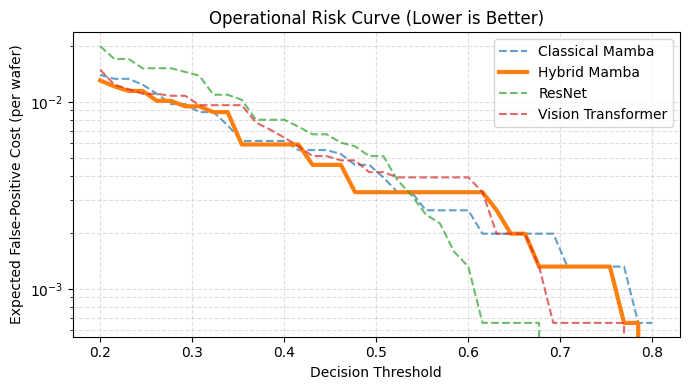

In [47]:
# ------------------ RISK CURVE (FALSE POSITIVE COST) ------------------

COST = {
    "Near_Full": 5.0,
    "Random": 2.0,
}

ts = np.linspace(0.2, 0.8, 40)

plt.figure(figsize=(7, 4))

for name, (y_true, y_prob, _) in models.items():
    costs = []
    for t in ts:
        y_p = (y_prob >= t).astype(int)
        c = 0.0
        for cls, w in COST.items():
            i = CLASSES.index(cls)
            fp = ((y_true[:, i] == 0) & (y_p[:, i] == 1)).sum()
            c += w * fp
        costs.append(c / y_true.shape[0])

    if name == "Hybrid Mamba":
        plt.plot(ts, costs, linewidth=3, label=name)
    else:
        plt.plot(ts, costs, linestyle="--", alpha=0.7, label=name)

plt.yscale("log")
plt.xlabel("Decision Threshold")
plt.ylabel("Expected False-Positive Cost (per wafer)")
plt.title("Operational Risk Curve (Lower is Better)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()